<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None
Accuracy Score=97.37%
Accuracy Metric=
                  precision    recall  f1-score   support

    Iris-setosa      1.000     1.000     1.000        12
Iris-versicolor      0.929     1.000     0.963        13
 Iris-virginica      1.000     0.923     0.960        13

       accuracy                          0.974        38
      macro avg      0.976     0.974     0.974        38
   weighted avg      0.976     0.974     0.974        38



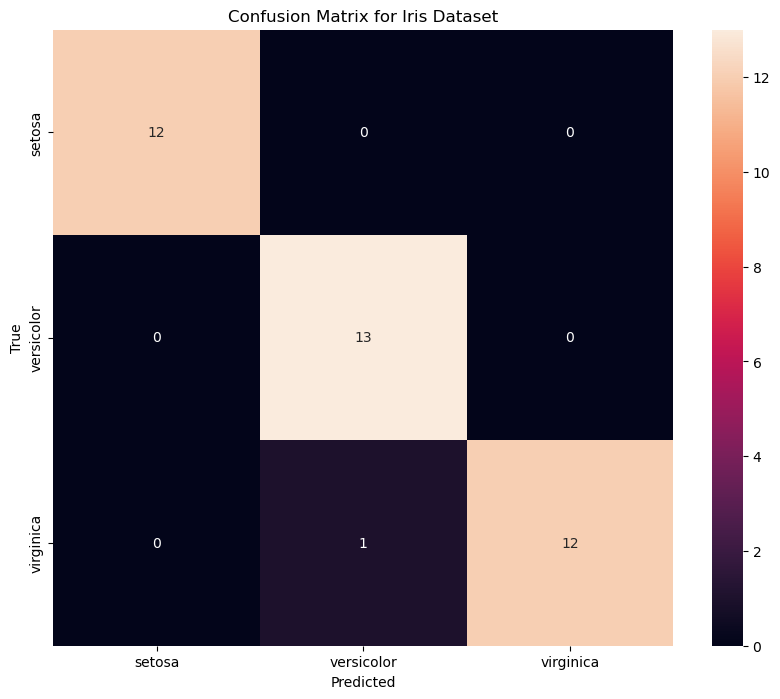

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV,train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.datasets import load_iris
iris=load_iris()
inf=pd.read_csv(r'IRIS.csv')
print(inf.info())
knn=KNeighborsClassifier()
X=inf.drop('species',axis='columns')
Y=inf['species']
X_train, X_test, y_train, y_test =train_test_split(X,Y,test_size=0.25,shuffle=True,stratify=Y,random_state=42)
result=[]
for i in range(1,10):
    bestKNN=GridSearchCV(knn,{
            'n_neighbors':[i]
        },cv=5,return_train_score=False)
    bestKNN.fit(X_train,y_train)
    result.append(bestKNN.cv_results_)
#print(result)
res=pd.DataFrame(result)
res1=res[['params','mean_test_score']]
knn=KNeighborsClassifier(bestKNN.best_params_['n_neighbors'])
knn.fit(X_train,y_train)
pred=knn.predict(X_test)
pred_vs_test = pd.DataFrame({
    'Predicted': pred, 
    'Actual': y_test.values  # Always use dictionary while creating a dataframe
})
#print(pred_vs_test)
print(f"Accuracy Score={accuracy_score(y_test,pred)*100:.2f}%")
print("Accuracy Metric=\n",classification_report(y_test,pred,digits=3))
cm=confusion_matrix(y_test,pred,)
plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True,xticklabels=iris.target_names,yticklabels=iris.target_names)
plt.title("Confusion Matrix for Iris Dataset")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()